In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("dataset.csv")

In [3]:
data.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [4]:
data.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,79.0,0,0,No Info,23.86,5.7,85,0
7,Male,42.0,0,0,never,33.64,4.8,145,0
8,Female,32.0,0,0,never,27.32,5.0,100,0
9,Female,53.0,0,0,never,27.32,6.1,85,0


In [5]:
data['gender'] = data['gender'].map({'Male':0, 'Female':1})

In [6]:
data.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,1,80.0,0,1,never,25.19,6.6,140,0
1,1,54.0,0,0,No Info,27.32,6.6,80,0
2,0,28.0,0,0,never,27.32,5.7,158,0
3,1,36.0,0,0,current,23.45,5.0,155,0
4,0,76.0,1,1,current,20.14,4.8,155,0
5,1,20.0,0,0,never,27.32,6.6,85,0
6,1,79.0,0,0,No Info,23.86,5.7,85,0
7,0,42.0,0,0,never,33.64,4.8,145,0
8,1,32.0,0,0,never,27.32,5.0,100,0
9,1,53.0,0,0,never,27.32,6.1,85,0


In [7]:
data['smoking_history']=data['smoking_history'].map({'never':0, 'No Info':1,'former':1 ,'current':2})

In [52]:
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,1,80,0,1,0.0,25.19,6.6,140,0
1,1,54,0,0,1.0,27.32,6.6,80,0
2,0,28,0,0,0.0,27.32,5.7,158,0
3,1,36,0,0,2.0,23.45,5.0,155,0
4,0,76,1,1,2.0,20.14,4.8,155,0


In [10]:
data['age']=data['age'].astype(int)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score


X = data[['gender','age','hypertension','heart_disease','smoking_history','bmi','HbA1c_level','blood_glucose_level']]
Y = data['diabetes']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42, shuffle=True)


In [20]:
model = RandomForestClassifier(n_estimators=100, random_state=400)

In [21]:
model.fit(X_train, Y_train)

RandomForestClassifier(random_state=400)

In [22]:
predict = model.predict(X_test)

In [23]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, Y, cv=skf, scoring='accuracy')
print(f"Accuracy per fold: {scores * 100}")
print(f"Mean Accuracy: {scores.mean() * 100:.2f}% (+/- {scores.std() * 100:.2f}%)")


Accuracy per fold: [93.20652174 91.0326087  88.58695652 89.13043478 89.10081744]
Mean Accuracy: 90.21% (+/- 1.71%)


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [25]:
precision = precision_score(Y_test, predict)
precision*100

88.52459016393442

In [48]:
acc=accuracy_score(Y_test, predict)
acc 

0.8913043478260869

In [26]:
recall = recall_score(Y_test, predict)
recall*100

89.50276243093923

In [27]:
f1score = f1_score(Y_test, predict)
f1score*100

89.01098901098901

In [28]:
con = confusion_matrix(Y_test, predict)
con

array([[166,  21],
       [ 19, 162]], dtype=int64)

In [29]:
data.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [56]:
 def predict_diabetes():
    gender = int(input("Gender: "))
    age = int(input("Age: "))
    hypertension = int(input("Hypertension : "))
    heart_disease = int(input("Heart Disease: "))
    bmi = float(input("BMI: "))
    HbA1c_level = float(input("sugar level: "))
    blood_glucose_level = float(input("Blood Glucose Level: "))
    smoking_history = int(input("smoking: "))
    
    
    patient_features = pd.DataFrame([[
        gender, age, hypertension, heart_disease, smoking_history, bmi, HbA1c_level, blood_glucose_level, 

    
    ]], columns=['gender', 'age', 'hypertension', 'heart_disease','smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level'],)
    
    result = model.predict(patient_features)[0]
    
    print("\n--- Result ---")
    if result == 1:
        print("Prediction: Diabetic / High Risk")
    else:
        print("Prediction: Healthy / Low Risk")

predict_diabetes()

Gender:  1
Age:  57
Hypertension :  1
Heart Disease:  0
BMI:  27.9
sugar level:  6.6
Blood Glucose Level:  126
smoking:  0



--- Result ---
Prediction: Healthy / Low Risk


In [42]:
 def predict_diabetes():
    gender = int(input("Gender: "))
    age = int(input("Age: "))
    hypertension = int(input("Hypertension : "))
    heart_disease = int(input("Heart Disease: "))
    bmi = float(input("BMI: "))
    HbA1c_level = float(input("sugar level: "))
    blood_glucose_level = float(input("Blood Glucose Level: "))
    smoking_history = int(input("smoking: "))
    
    
    patient_features = pd.DataFrame([[
        gender, age, hypertension, heart_disease, smoking_history, bmi, HbA1c_level, blood_glucose_level, 

    
    ]], columns=['gender', 'age', 'hypertension', 'heart_disease','smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level'],)
    
    result = model.predict(patient_features)[0]
    
    print("\n--- Result ---")
    if result == 1:
        print("Prediction: Diabetic / High Risk")
    else:
        print("Prediction: Healthy / Low Risk")

predict_diabetes()

Gender:  1
Age:  61
Hypertension :  0
Heart Disease:  0
BMI:  31.6
sugar level:  5.8
Blood Glucose Level:  159
smoking:  0



--- Result ---
Prediction: Diabetic / High Risk


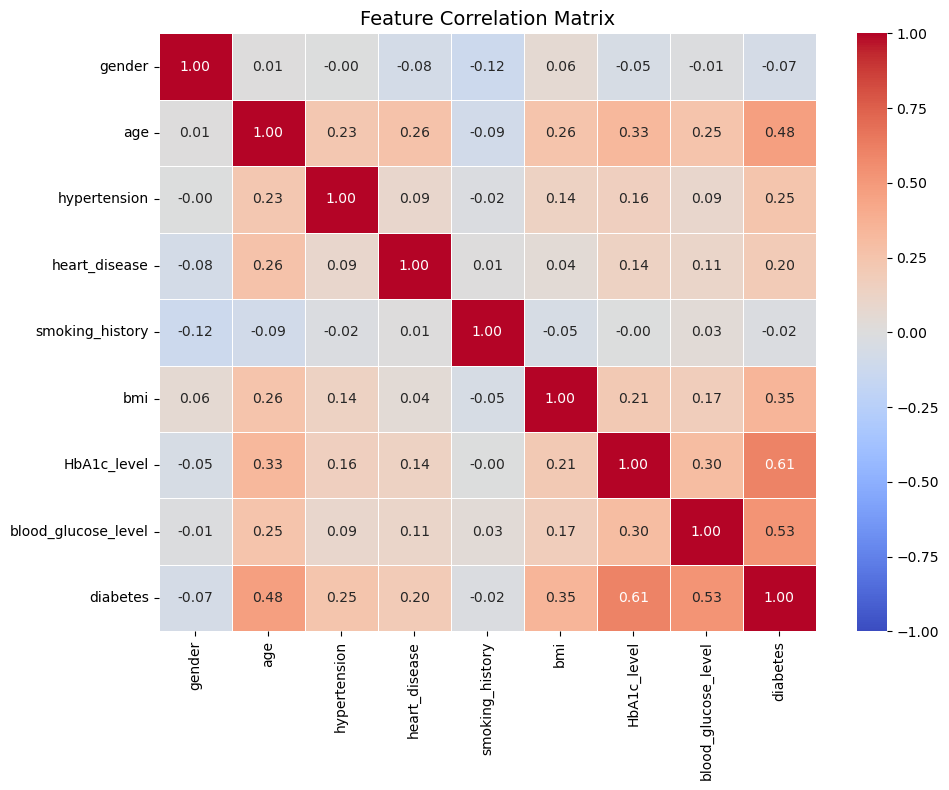

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = data.corr(numeric_only=True)

# Set figure size
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show numeric values inside cells
    fmt=".2f",           # Format numbers to 2 decimal places
    cmap='coolwarm',     # Color palette (Red = High +, Blue = High -)
    vmin=-1, vmax=1,     # Correlation range boundaries
    linewidths=0.5,      # Grid line width between cells
    cbar=True            # Show colorbar
)

plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()